## Problem 2.2
(Use Python only.) Consider the normal random variables $X_1, X_2$ in $\mathbb{R}^2$ with means $(0.7, 0)$ and $(0.7, 0)$ respectively, and with covariance $\begin{pmatrix} 1 & 1 \\ 1 & 2 \end{pmatrix}$.

-(a) Simulate 10 (and then 100, seperately) values of from both distributions.

-(b) For both of the above cases, plot the values with different colours for each distribution.

-(c) Run LDA as a classification algorithm on using the correct covariance matrix and means. Plot the decision boundary and give the equation. Calculate the accuracy on the data sets above.

-(d) Run quadratic discriminant analysis assuming the covariance matrix (but not the means) is unknown, and estimated through maximum likelihood. Calculate the accuracy on the data sets above.

-(e) Do the same thing assuming the mean is also unknown

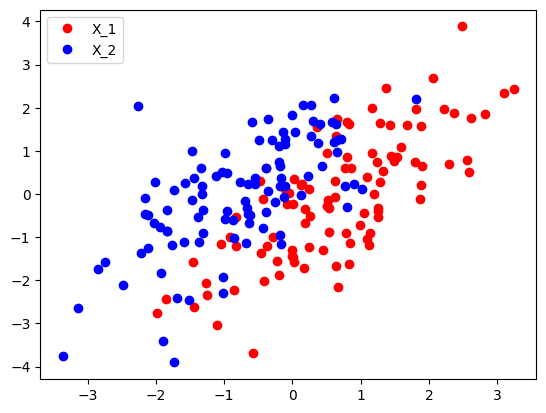

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Define the common parameters
mean_1 = [0.7, 0]
mean_2 = [-0.7, 0]
covariance_matrix = [[1, 1], 
                     [1, 2]]

# --- (a) Simulate 10 values ---
n_samples = 100
# The 'size' parameter dictates the number of samples (rows) to draw.
X_1 = np.random.multivariate_normal(mean_1, covariance_matrix, size=n_samples)
X_2 = np.random.multivariate_normal(mean_2, covariance_matrix, size=n_samples)
plt.plot(X_1[:, 0], X_1[:, 1], 'ro', label='X_1')
plt.plot(X_2[:, 0], X_2[:, 1], 'bo', label="X_2")
plt.legend()

## LDA
First we consider the LDA case:
Let 
$$w = 2(\hat{\mu}_+ - \hat{\mu}_-)^T\hat{\Sigma}^{-1}$$
$$b = \hat{\mu}_-^T\hat{\Sigma}^{-1}\hat{\mu}_- - \hat{\mu}_-^T\hat{\Sigma}^{-1}\hat{\mu}_-$$
then the decision boundary is given by
$$w^Tx+b > 0$$


Text(0.5, 1.0, 'LDA Decision Boundary')

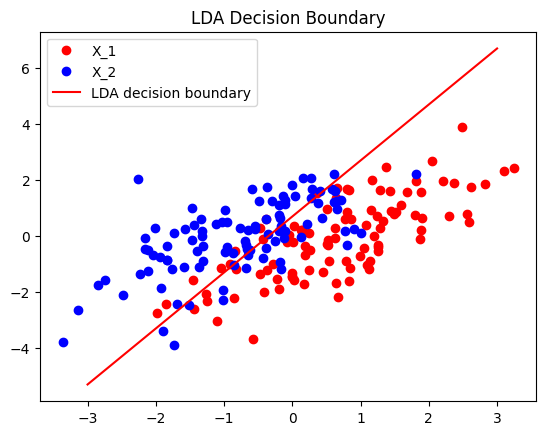

In [51]:
w = 2*(np.array(mean_1) - np.array(mean_2)).T @ np.linalg.inv(np.array(covariance_matrix))
b = (np.array(mean_2).T @ np.linalg.inv(np.array(covariance_matrix)) @ np.array(mean_2)) + (np.array(mean_1).T @ np.linalg.inv(np.array(covariance_matrix)) @ np.array(mean_1)) + 2*np.log(0.5/0.5)


x1 = np.linspace(-3, 3, 500)
# Löse w1*x1 + w2*x2 + b = 0 nach x2 auf
x2 = (-b - w[0]*x1) / w[1]
plt.plot(X_1[:, 0], X_1[:, 1], 'ro', label='X_1')
plt.plot(X_2[:, 0], X_2[:, 1], 'bo', label="X_2")
plt.plot(x1, x2, 'r-', label='LDA decision boundary')
plt.legend()
plt.title('LDA Decision Boundary')

For quadratic discriminant analysis we need to compute the likelihood estimation of the covarince

In [52]:
cov_X_1 = np.cov(X_1.T)
cov_X_2 = np.cov(X_2.T)
print(cov_X_1)
print(cov_X_2)

[[1.23239928 1.19785251]
 [1.19785251 2.0845304 ]]
[[1.05354586 0.89018001]
 [0.89018001 1.71744873]]


Now we can run '##Quadratic Discriminant Analysis

Let 
$$w = 2(\hat{\mu}_+ - \hat{\mu}_-)^T\hat{\Sigma}^{-1}$$
$$b = \hat{\mu}_-^T\hat{\Sigma}^{-1}\hat{\mu}_- - \hat{\mu}_-^T\hat{\Sigma}^{-1}\hat{\mu}_-$$
then the decision boundary is given by
$$w^Tx+b = 0$$

C:\Users\User\AppData\Local\Temp\ipykernel_21840\1042805058.py:14: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, F, levels=[0], colors='red', label= "QDA decision boundary")


Text(0.5, 1.0, 'QDA Decision Boundary')

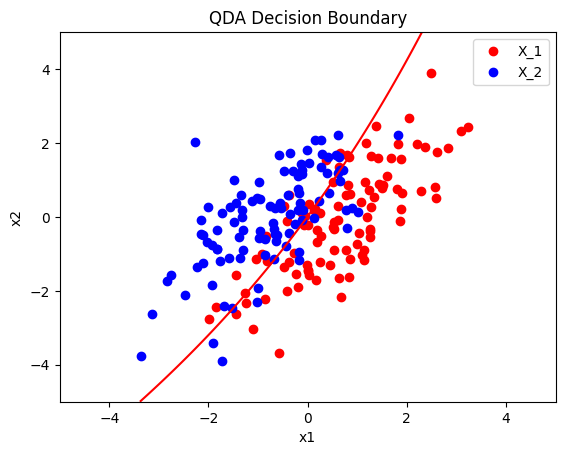

In [53]:
A = 0.5 * (np.linalg.inv(cov_X_1) - np.linalg.inv(cov_X_2))
b = (np.array(mean_2).T @ np.linalg.inv(cov_X_2)) - (np.array(mean_1).T @ np.linalg.inv(cov_X_1))
c = 0.5 *(np.array(mean_1).T @ np.linalg.inv(cov_X_1) @ np.array(mean_1)) - 0.5*(np.array(mean_2).T @ np.linalg.inv(cov_X_2) @ np.array(mean_2)) + 0.5*np.log(np.linalg.det(cov_X_2)/np.linalg.det(cov_X_1))

x1 = np.linspace(-5, 5, 500)
x2 = np.linspace(-5, 5, 500)
X1, X2 = np.meshgrid(x1, x2)

# Berechne die quadratische Gleichung an jedem Gitterpunkt
F = A[0,0]*X1**2 + (A[0,1]+A[1,0])*X1*X2 + A[1,1]*X2**2 + b[0]*X1 + b[1]*X2 + c

plt.plot(X_1[:, 0], X_1[:, 1], 'ro', label='X_1')
plt.plot(X_2[:, 0], X_2[:, 1], 'bo', label="X_2")
plt.contour(X1, X2, F, levels=[0], colors='red', label= "QDA decision boundary")
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('QDA Decision Boundary')

Now we perform the same by estimating the means as well

C:\Users\User\AppData\Local\Temp\ipykernel_21840\2575926653.py:13: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, F, levels=[0], colors='red', label= "QDA decision boundary")


Text(0.5, 1.0, 'QDA with estimated means')

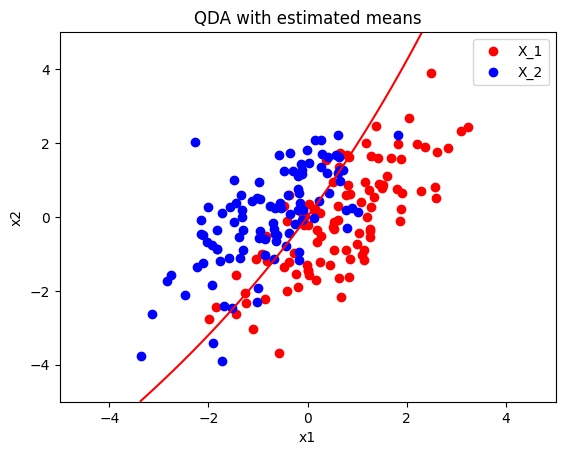

In [54]:
estimate_means_1 = np.mean(X_1, axis=0)
estimate_means_2 = np.mean(X_2, axis=0)

x1 = np.linspace(-5, 5, 500)
x2 = np.linspace(-5, 5, 500)
X1, X2 = np.meshgrid(x1, x2)

# Berechne die quadratische Gleichung an jedem Gitterpunkt
F = A[0,0]*X1**2 + (A[0,1]+A[1,0])*X1*X2 + A[1,1]*X2**2 + b[0]*X1 + b[1]*X2 + c

plt.plot(X_1[:, 0], X_1[:, 1], 'ro', label='X_1')
plt.plot(X_2[:, 0], X_2[:, 1], 'bo', label="X_2")
plt.contour(X1, X2, F, levels=[0], colors='red', label= "QDA decision boundary")
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('QDA with estimated means')